In [1]:
!pip -q install "transformers>=4.52.0" accelerate opencv-python

In [2]:
# 导入库
import json
import gc
from pathlib import Path

import cv2
import numpy as np
import torch
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from transformers import (
    AutoProcessor,
    AutoModelForZeroShotObjectDetection,
    SamProcessor,
    SamModel,
)

In [3]:
# 加载模型
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

GROUNDING_MODEL_ID = "IDEA-Research/grounding-dino-base"
SAM_MODEL_ID = "facebook/sam-vit-base"

grounding_processor = AutoProcessor.from_pretrained(GROUNDING_MODEL_ID)
grounding_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    GROUNDING_MODEL_ID
).to(DEVICE).eval()

sam_processor = SamProcessor.from_pretrained(SAM_MODEL_ID)
sam_model = SamModel.from_pretrained(SAM_MODEL_ID).to(DEVICE).eval()

print("DEVICE:", DEVICE)

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

DEVICE: cuda


In [4]:
# 基础参数
# GroundingDINO 基础阈值
BOX_THRESHOLD = 0.30
TEXT_THRESHOLD = 0.25

# 每个 label 最多尝试前几个候选框
MAX_BOXES_PER_LABEL = 3

# mask 面积过滤
MIN_AREA_RATIO = 0.002
MAX_AREA_RATIO = 0.60

In [5]:
# 检测、分割、形态学处理
def detect_boxes(image, prompt, box_threshold=BOX_THRESHOLD, text_threshold=TEXT_THRESHOLD):
    inputs = grounding_processor(
        images=image,
        text=[[prompt.lower()]],
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        outputs = grounding_model(**inputs)

    result = grounding_processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=box_threshold,
        text_threshold=text_threshold,
        target_sizes=[(image.height, image.width)]
    )[0]

    boxes = result["boxes"].detach().cpu().numpy()
    scores = result["scores"].detach().cpu().numpy()

    if len(scores) == 0:
        return np.empty((0, 4), dtype=np.float32), np.empty((0,), dtype=np.float32)

    order = np.argsort(scores)[::-1]
    return boxes[order], scores[order]


def segment_one_box(image, box):
    inputs = sam_processor(
        images=image,
        input_boxes=[[[float(v) for v in box]]],
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        outputs = sam_model(**inputs, multimask_output=False)

    masks = sam_processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"].cpu(),
        inputs["reshaped_input_sizes"].cpu(),
    )

    mask = masks[0]
    while hasattr(mask, "ndim") and mask.ndim > 2:
        mask = mask[0]

    mask = np.array(mask)
    return (mask > 0).astype(np.uint8)


def morph_close(mask, k=5):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    closed = cv2.morphologyEx((mask * 255).astype(np.uint8), cv2.MORPH_CLOSE, kernel)
    return (closed > 127).astype(np.uint8)


def merge_binary_masks(masks):
    merged = np.zeros_like(masks[0], dtype=np.uint8)
    for m in masks:
        merged = np.logical_or(merged, m > 0)
    return merged.astype(np.uint8)


def area_ratio(mask):
    return float(mask.sum()) / float(mask.shape[0] * mask.shape[1])

In [6]:
# 可视化函数
def show_boxes(image, boxes, scores=None, figsize=(8, 8)):
    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(image)

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        w, h = x2 - x1, y2 - y1
        rect = patches.Rectangle(
            (x1, y1), w, h,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)

        if scores is not None:
            ax.text(
                x1, max(0, y1 - 5),
                f"{i}: {scores[i]:.3f}",
                color="yellow",
                fontsize=10,
                bbox=dict(facecolor="black", alpha=0.6, pad=2)
            )

    plt.axis("off")
    plt.show()


def show_mask_overlay(image, mask, alpha=0.45, figsize=(8, 8)):
    image_np = np.array(image).copy()

    overlay = image_np.copy()
    overlay[mask > 0] = [255, 0, 0]

    blended = (image_np * (1 - alpha) + overlay * alpha).astype(np.uint8)

    plt.figure(figsize=figsize)
    plt.imshow(blended)
    plt.axis("off")
    plt.show()

In [7]:
PROMPT_FALLBACKS = {
    "hairpin": ["flower hairpin", "hairpin", "hair accessory"],
    "bow": ["ribbon bow", "bow", "ribbon"],
    "ribbon": ["ribbon", "hair ribbon", "ribbon bow"],
    "socks": ["knee high socks", "socks"],
    "bracelet": ["bracelet", "wrist bracelet"],
    "kimono": ["kimono"],
    "robe": ["robe"],
    "scroll": ["scroll"],
    "fan": ["fan"],
    "flower": ["flower"],
    "plate": ["plate"],
    "mouse": ["mouse"],
    "cat": ["cat"],
    "hat": ["hat"],
    "hair": ["hair"],
    "braid": ["braid"],
    "sandals": ["sandals"],
}


def unique_keep_order(items):
    out, seen = [], set()
    for x in items:
        x = x.lower().strip()
        if x and x not in seen:
            seen.add(x)
            out.append(x)
    return out


def build_prompt_candidates(label, phrase=None):
    cands = []
    if phrase:
        cands.append(phrase)
    cands.extend(PROMPT_FALLBACKS.get(label, []))
    cands.append(label)
    return unique_keep_order(cands)


def kernel_size_for_label(label):
    if label in {"hairpin", "bracelet", "ribbon", "bow"}:
        return 3
    if label in {"flower", "plate", "mouse", "cat", "hat"}:
        return 5
    return 7


def max_box_area_ratio_for_label(label):
    if label in {"hairpin", "bracelet", "ribbon", "bow"}:
        return 0.10
    if label in {"flower", "plate", "mouse", "cat", "hat"}:
        return 0.25
    return 0.85


def detection_schedule_for_label(label):
    if label in {"hairpin", "bracelet", "ribbon", "bow"}:
        return [(0.30, 0.25), (0.25, 0.20)]
    return [(0.30, 0.25)]


def box_area_ratio(box, image):
    x1, y1, x2, y2 = box
    area = max(0, x2 - x1) * max(0, y2 - y1)
    return area / float(image.width * image.height)


def filter_boxes_by_size(boxes, scores, image, label):
    max_ratio = max_box_area_ratio_for_label(label)

    kept_boxes = []
    kept_scores = []

    for box, score in zip(boxes, scores):
        ar = box_area_ratio(box, image)
        if ar <= max_ratio:
            kept_boxes.append(box)
            kept_scores.append(score)

    if len(kept_boxes) == 0:
        return np.empty((0, 4), dtype=np.float32), np.empty((0,), dtype=np.float32)

    return np.array(kept_boxes), np.array(kept_scores)

In [8]:
# 核心函数（一图多标签
def process_one_image_labels(image, phrases, labels=None, debug=False):
    """
    image: PIL.Image
    phrases: perception 里来的 object_phrases，或你手工指定的 phrase
    labels:  对应的 segmentation label；如果不传，就默认等于 phrases
    debug:   是否打印中间信息
    """
    if labels is None:
        labels = phrases

    results = []
    failed_labels = []

    for i, phrase in enumerate(phrases):
        label = labels[i] if i < len(labels) else phrase
        prompt_candidates = build_prompt_candidates(label, phrase)

        found = False

        if debug:
            print("=" * 60)
            print("LABEL:", label)
            print("PHRASE:", phrase)
            print("PROMPTS:", prompt_candidates)

        for prompt in prompt_candidates:
            kept_masks = []
            top_score = None
            used_boxes = []

            for bt, tt in detection_schedule_for_label(label):
                boxes, scores = detect_boxes(image, prompt, bt, tt)

                if debug:
                    print(f"  prompt={prompt} | bt={bt} tt={tt} | raw_boxes={len(boxes)}")

                if len(boxes) == 0:
                    continue

                boxes, scores = filter_boxes_by_size(boxes, scores, image, label)

                if debug:
                    print(f"  after size filter: {len(boxes)}")

                if len(boxes) == 0:
                    continue

                for box, score in zip(boxes[:MAX_BOXES_PER_LABEL], scores[:MAX_BOXES_PER_LABEL]):
                    mask = segment_one_box(image, box)
                    mask = morph_close(mask, k=kernel_size_for_label(label))

                    ar = area_ratio(mask)
                    if MIN_AREA_RATIO <= ar <= MAX_AREA_RATIO:
                        kept_masks.append(mask)
                        used_boxes.append(box.tolist())
                        if top_score is None:
                            top_score = float(score)

                if kept_masks:
                    merged_mask = merge_binary_masks(kept_masks)

                    results.append({
                        "label": label,
                        "phrase": phrase,
                        "prompt_used": prompt,
                        "score": top_score if top_score is not None else 0.0,
                        "mask": merged_mask,
                        "num_regions": len(kept_masks),
                        "boxes_used": used_boxes,
                        "mask_area_ratio": area_ratio(merged_mask),
                    })
                    found = True
                    break

            if found:
                break

        if not found:
            failed_labels.append(label)

    return results, failed_labels

In [9]:
from pathlib import Path

# ========= 批量 segmentation 配置 =========

PERCEPTION_JSONL = Path("/kaggle/input/datasets/yejixuan/perception1/perception_results (3).jsonl")

# 这里不用 image_root 兜底，因为你的 jsonl 里存的是旧绝对路径，不是相对路径
IMAGE_ROOT = None

# 旧路径 -> 新路径 的前缀映射
OLD_IMAGE_PREFIX = "/kaggle/input/datasets/yejixuan/real-dataset"
NEW_IMAGE_PREFIX = "/kaggle/input/datasets/yejixuan/real-dataset2"

WORK_DIR = Path("/kaggle/working/batch_segmentation")
MASK_DIR = WORK_DIR / "masks"
OVERLAY_DIR = WORK_DIR / "overlays"
RESULT_JSONL = WORK_DIR / "segmentation_results.jsonl"
ERROR_JSONL = WORK_DIR / "segmentation_errors.jsonl"

MASK_DIR.mkdir(parents=True, exist_ok=True)
OVERLAY_DIR.mkdir(parents=True, exist_ok=True)

SAVE_OVERLAY = True
SKIP_DONE = True
DEBUG = False
MAX_IMAGES = None
CROSS_LABEL_IOU_THR = 0.90

ALIASES = {
    "flower hairpin": "hairpin",
    "hair accessory": "hairpin",
    "bows": "bow",
    "ribbon bow": "bow",
    "hair ribbon": "ribbon",
    "knee high socks": "socks",
    "knee-high socks": "socks",
    "spectacles": "glasses",
    "kimonono": "kimono",
}

DROP_LABELS = {
    "background",
    "text",
    "year",
    "new year",
    "pattern",
}

print("PERCEPTION_JSONL =", PERCEPTION_JSONL)
print("PERCEPTION_JSONL exists =", PERCEPTION_JSONL.exists())
print("OLD_IMAGE_PREFIX =", OLD_IMAGE_PREFIX)
print("NEW_IMAGE_PREFIX =", NEW_IMAGE_PREFIX)

PERCEPTION_JSONL = /kaggle/input/datasets/yejixuan/perception1/perception_results (3).jsonl
PERCEPTION_JSONL exists = True
OLD_IMAGE_PREFIX = /kaggle/input/datasets/yejixuan/real-dataset
NEW_IMAGE_PREFIX = /kaggle/input/datasets/yejixuan/real-dataset2


In [10]:
# 9
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def append_jsonl(path, obj):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False) + "\n")


def read_done_ids(jsonl_path):
    done = set()
    if not jsonl_path.exists():
        return done

    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
                if "image_id" in obj:
                    done.add(obj["image_id"])
            except:
                pass
    return done


def unique_keep_order_pairs(phrases, labels):
    out_phrases, out_labels = [], []
    seen = set()
    for p, l in zip(phrases, labels):
        key = (p.lower().strip(), l.lower().strip())
        if key not in seen:
            seen.add(key)
            out_phrases.append(p)
            out_labels.append(l)
    return out_phrases, out_labels


def normalize_label(x):
    if x is None:
        return None
    x = str(x).lower().strip()
    x = x.replace("_", " ")
    x = " ".join(x.split())

    x = ALIASES.get(x, x)

    if x in DROP_LABELS:
        return None
    if len(x) == 0:
        return None
    return x


def parse_object_words(v):
    if v is None:
        return []

    if isinstance(v, list):
        return [str(x).strip() for x in v if str(x).strip()]

    if isinstance(v, str):
        s = v.strip()
        if not s:
            return []
        # 兼容 "a, b, c"
        if "," in s:
            return [x.strip() for x in s.split(",") if x.strip()]
        return [s]

    return []


def build_phrases_labels_from_perception(object_words):
    phrases = []
    labels = []

    for obj in object_words:
        phrase = str(obj).lower().strip()
        label = normalize_label(phrase)
        if label is None:
            continue

        phrases.append(phrase)
        labels.append(label)

    phrases, labels = unique_keep_order_pairs(phrases, labels)
    return phrases, labels


def get_caption(item):
    for k in ["caption", "image_caption", "description", "desc"]:
        if k in item and item[k]:
            return str(item[k]).strip()
    return ""


def get_object_words(item):
    for k in ["object_words", "objects", "labels", "object_labels"]:
        if k in item:
            return parse_object_words(item[k])
    return []


def resolve_image_path(item, image_root=None):
    candidate_keys = [
        "resized_path",
        "resized_image_path",
        "image_path",
        "img_path",
        "path",
        "file_path",
    ]

    candidates = []
    for k in candidate_keys:
        if k in item and item[k]:
            candidates.append(str(item[k]))

    for p_str in candidates:
        p = Path(p_str)

        # 1) 直接检查原路径
        if p.exists():
            return p

        # 2) 旧绝对路径 -> 新绝对路径
        if p_str.startswith(OLD_IMAGE_PREFIX):
            remapped = p_str.replace(OLD_IMAGE_PREFIX, NEW_IMAGE_PREFIX, 1)
            q = Path(remapped)
            if q.exists():
                return q

        # 3) 如果是相对路径，再尝试 IMAGE_ROOT
        if image_root is not None and not p.is_absolute():
            q = image_root / p
            if q.exists():
                return q

    return None


def make_image_id(item, image_path, idx):
    for k in ["image_id", "id", "uid"]:
        if k in item and item[k]:
            return str(item[k])

    return f"{idx:06d}_{image_path.stem}"


import re

def safe_name(x):
    x = str(x).strip().lower()

    # 先把常见连接符和路径符号处理掉
    x = x.replace("&", "_and_")
    x = x.replace("/", "_")
    x = x.replace("\\", "_")
    x = x.replace(" ", "_")

    # 只保留安全字符
    x = re.sub(r"[^a-z0-9._-]", "_", x)

    # 压缩重复下划线
    x = re.sub(r"_+", "_", x).strip("._")

    return x[:80] if x else "mask"

In [11]:
rows = load_jsonl(PERCEPTION_JSONL)
print("num rows =", len(rows))
print(rows[0])

item = rows[0]
print("old path =", item.get("resized_path", item.get("image_path")))

print("resolved =", resolve_image_path(item, IMAGE_ROOT))
print("exists =", resolve_image_path(item, IMAGE_ROOT).exists())

num rows = 314
{'image_path': '/kaggle/input/datasets/yejixuan/real-dataset/85013611_p0_master1200.jpg', 'resized_path': '/kaggle/working/internvl_perception/resized_1024/85013611_p0_master1200.jpg', 'resized_width': 732, 'resized_height': 1024, 'caption': 'An animated character with white hair, cat ears, and a blue and white outfit sings into a microphone, with a teddy bear and a penguin in the background.', 'raw_object_output': 'microphone, teddy bear, penguin, star accessory, blue vest, white hair, blue eyes, microphone stand', 'object_phrases': ['microphone', 'teddy bear', 'penguin', 'star accessory', 'blue vest', 'white hair', 'blue eye', 'microphone stand'], 'object_words': ['microphone', 'bear', 'penguin', 'accessory', 'vest', 'hair', 'eye', 'stand']}
old path = /kaggle/working/internvl_perception/resized_1024/85013611_p0_master1200.jpg
resolved = /kaggle/input/datasets/yejixuan/real-dataset2/85013611_p0_master1200.jpg
exists = True


In [12]:
def mask_iou(mask_a, mask_b):
    a = mask_a > 0
    b = mask_b > 0
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter) / float(union + 1e-8)


def connected_components_count(mask):
    mask = (mask > 0).astype(np.uint8)
    num_labels, _ = cv2.connectedComponents(mask)
    return max(0, num_labels - 1)


def classify_mask_type(mask, merged_group_size):
    cc = connected_components_count(mask)

    if merged_group_size > 1:
        return "multi-class"

    if cc <= 1:
        return "single-instance"
    return "multi-instance"


def merge_overlapping_results(results, iou_thr=CROSS_LABEL_IOU_THR):
    """
    输入: process_one_image_labels 的结果
    输出: 合并后的结果
    """
    if len(results) == 0:
        return []

    n = len(results)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    # 不同 label 之间如果 IoU 很高，合并
    for i in range(n):
        for j in range(i + 1, n):
            iou = mask_iou(results[i]["mask"], results[j]["mask"])
            if iou > iou_thr:
                union(i, j)

    groups = {}
    for i in range(n):
        root = find(i)
        groups.setdefault(root, []).append(i)

    merged_results = []

    for _, idxs in groups.items():
        group = [results[i] for i in idxs]

        if len(group) == 1:
            r = group[0]
            merged_mask = (r["mask"] > 0).astype(np.uint8)

            merged_results.append({
                "label": r["label"],
                "phrase": r["phrase"],
                "prompt_used": r["prompt_used"],
                "score": float(r["score"]),
                "mask": merged_mask,
                "num_regions": connected_components_count(merged_mask),
                "boxes_used": r["boxes_used"],
                "mask_area_ratio": area_ratio(merged_mask),
                "mask_type": classify_mask_type(merged_mask, 1),
            })
        else:
            merged_mask = merge_binary_masks([g["mask"] for g in group])

            # 再做一次 closing，边缘更顺
            merged_mask = morph_close(merged_mask, k=5)

            merged_label = "_and_".join(sorted(set(g["label"] for g in group)))
            merged_phrase = " | ".join(sorted(set(g["phrase"] for g in group)))
            merged_prompt = " | ".join(sorted(set(g["prompt_used"] for g in group)))
            merged_boxes = []
            merged_score = 0.0

            for g in group:
                merged_boxes.extend(g["boxes_used"])
                merged_score = max(merged_score, float(g["score"]))

            merged_results.append({
                "label": merged_label,
                "phrase": merged_phrase,
                "prompt_used": merged_prompt,
                "score": merged_score,
                "mask": merged_mask,
                "num_regions": connected_components_count(merged_mask),
                "boxes_used": merged_boxes,
                "mask_area_ratio": area_ratio(merged_mask),
                "mask_type": classify_mask_type(merged_mask, len(group)),
            })

    return merged_results


def save_overlay_image(image, results, save_path):
    image_np = np.array(image).copy()
    overlay = image_np.copy()

    colors = [
        [255, 0, 0],
        [0, 255, 0],
        [0, 0, 255],
        [255, 255, 0],
        [255, 0, 255],
        [0, 255, 255],
        [255, 128, 0],
        [128, 0, 255],
    ]

    for i, r in enumerate(results):
        color = np.array(colors[i % len(colors)], dtype=np.uint8)
        mask = r["mask"] > 0
        overlay[mask] = color

        ys, xs = np.where(mask)
        if len(xs) > 0 and len(ys) > 0:
            x0, y0 = int(xs.min()), int(ys.min())
            text = r["label"]
            cv2.putText(
                overlay,
                text,
                (x0, max(20, y0 + 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                tuple(int(v) for v in color.tolist()),
                2,
                cv2.LINE_AA
            )

    blended = (image_np * 0.6 + overlay * 0.4).astype(np.uint8)
    Image.fromarray(blended).save(save_path)

In [13]:
def run_one_perception_record(item, idx, debug=False):
    image_path = resolve_image_path(item, IMAGE_ROOT)

    if image_path is None:
        raise FileNotFoundError(f"Cannot resolve image path from item: {item}")

    image = Image.open(image_path).convert("RGB")

    caption = get_caption(item)
    object_words_raw = get_object_words(item)
    phrases, labels = build_phrases_labels_from_perception(object_words_raw)

    image_id = make_image_id(item, image_path, idx)

    if debug:
        print("=" * 80)
        print("image_id:", image_id)
        print("image_path:", image_path)
        print("caption:", caption)
        print("object_words_raw:", object_words_raw)
        print("phrases:", phrases)
        print("labels:", labels)

    # 没有有效 label，也要落盘，避免下次重复处理
    if len(phrases) == 0:
        return {
            "image_id": image_id,
            "source_image_path": str(image_path),
            "caption": caption,
            "object_words_raw": object_words_raw,
            "phrases": [],
            "labels": [],
            "failed_labels": [],
            "segmentation_candidates": [],
            "overlay_path": None,
            "status": "no_valid_labels",
        }

    # 复用你现有的核心函数
    results, failed_labels = process_one_image_labels(
        image=image,
        phrases=phrases,
        labels=labels,
        debug=debug
    )

    # 按论文补：跨 label 的高 IoU 合并
    results = merge_overlapping_results(results, iou_thr=CROSS_LABEL_IOU_THR)

    stem = image_id
    json_ready = []

    for i, r in enumerate(results):
        mask_name = f"{stem}_{i:02d}_{safe_name(r['label'])}.png"
        mask_path = MASK_DIR / mask_name

        Image.fromarray((r["mask"] * 255).astype(np.uint8)).save(mask_path)

        json_ready.append({
            "label": r["label"],
            "phrase": r["phrase"],
            "prompt_used": r["prompt_used"],
            "score": float(r["score"]),
            "num_regions": int(r["num_regions"]),
            "boxes_used": r["boxes_used"],
            "mask_area_ratio": float(r["mask_area_ratio"]),
            "mask_type": r["mask_type"],
            "mask_path": str(mask_path),
        })

    overlay_path = None
    if SAVE_OVERLAY and len(results) > 0:
        overlay_path = OVERLAY_DIR / f"{stem}.png"
        save_overlay_image(image, results, overlay_path)
        overlay_path = str(overlay_path)

    out = {
        "image_id": image_id,
        "source_image_path": str(image_path),
        "caption": caption,
        "object_words_raw": object_words_raw,
        "phrases": phrases,
        "labels": labels,
        "failed_labels": failed_labels,
        "segmentation_candidates": json_ready,
        "overlay_path": overlay_path,
        "status": "ok",
    }

    # 释放显存/内存
    del image
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return out

In [14]:
rows = load_jsonl(PERCEPTION_JSONL)
print("num perception rows =", len(rows))

if MAX_IMAGES is not None:
    rows = rows[:MAX_IMAGES]
    print("use first", len(rows), "rows")

test_idx = 0
test_item = rows[test_idx]

test_out = run_one_perception_record(test_item, idx=test_idx, debug=True)

print("\nstatus =", test_out["status"])
print("image_id =", test_out["image_id"])
print("source_image_path =", test_out["source_image_path"])
print("caption =", test_out["caption"])
print("phrases =", test_out["phrases"])
print("labels =", test_out["labels"])
print("failed_labels =", test_out["failed_labels"])
print("num segmentation_candidates =", len(test_out["segmentation_candidates"]))

for i, r in enumerate(test_out["segmentation_candidates"]):
    print(
        f"[{i}] label={r['label']} | "
        f"mask_type={r['mask_type']} | "
        f"score={r['score']:.4f} | "
        f"area={r['mask_area_ratio']:.4f}"
    )

num perception rows = 314
image_id: 000000_85013611_p0_master1200
image_path: /kaggle/input/datasets/yejixuan/real-dataset2/85013611_p0_master1200.jpg
caption: An animated character with white hair, cat ears, and a blue and white outfit sings into a microphone, with a teddy bear and a penguin in the background.
object_words_raw: ['microphone', 'bear', 'penguin', 'accessory', 'vest', 'hair', 'eye', 'stand']
phrases: ['microphone', 'bear', 'penguin', 'accessory', 'vest', 'hair', 'eye', 'stand']
labels: ['microphone', 'bear', 'penguin', 'accessory', 'vest', 'hair', 'eye', 'stand']
LABEL: microphone
PHRASE: microphone
PROMPTS: ['microphone']
  prompt=microphone | bt=0.3 tt=0.25 | raw_boxes=2
  after size filter: 2
LABEL: bear
PHRASE: bear
PROMPTS: ['bear']
  prompt=bear | bt=0.3 tt=0.25 | raw_boxes=1
  after size filter: 1
LABEL: penguin
PHRASE: penguin
PROMPTS: ['penguin']
  prompt=penguin | bt=0.3 tt=0.25 | raw_boxes=1
  after size filter: 1
LABEL: accessory
PHRASE: accessory
PROMPTS: ['

overlay: /kaggle/working/batch_segmentation/overlays/000000_85013611_p0_master1200.png


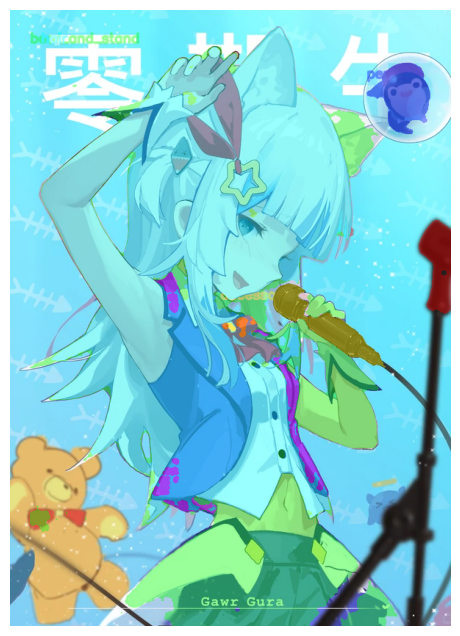

microphone | multi-instance | score = 0.7208 | area = 0.0172


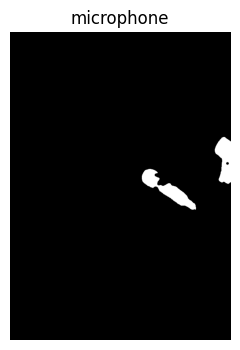

bear_and_stand | multi-class | score = 0.3971 | area = 0.4652


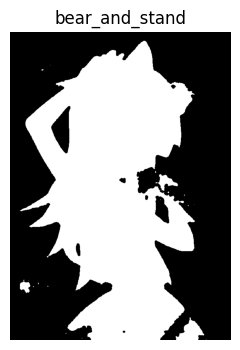

penguin | single-instance | score = 0.36 | area = 0.0101


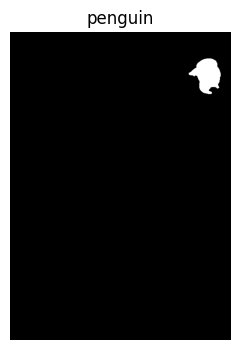

accessory | multi-instance | score = 0.3888 | area = 0.0152


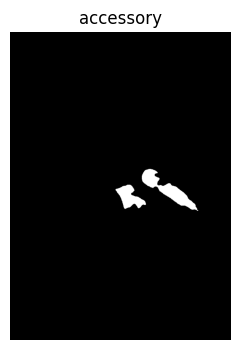

vest | multi-instance | score = 0.4431 | area = 0.0524


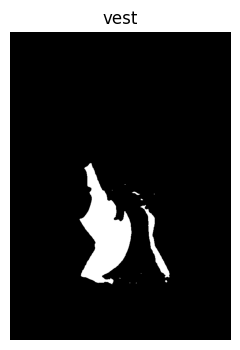

hair | multi-instance | score = 0.3075 | area = 0.3282


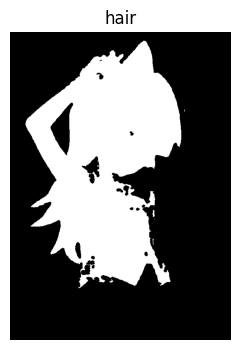

In [15]:
if test_out["overlay_path"] is not None:
    print("overlay:", test_out["overlay_path"])
    plt.figure(figsize=(8, 8))
    plt.imshow(Image.open(test_out["overlay_path"]))
    plt.axis("off")
    plt.show()

for r in test_out["segmentation_candidates"]:
    print(
        r["label"],
        "|", r["mask_type"],
        "| score =", round(r["score"], 4),
        "| area =", round(r["mask_area_ratio"], 4)
    )
    plt.figure(figsize=(4, 4))
    plt.imshow(Image.open(r["mask_path"]), cmap="gray")
    plt.title(r["label"])
    plt.axis("off")
    plt.show()

In [16]:
rows = load_jsonl(PERCEPTION_JSONL)

if MAX_IMAGES is not None:
    rows = rows[:MAX_IMAGES]

done_ids = read_done_ids(RESULT_JSONL) if SKIP_DONE else set()

print("total rows =", len(rows))
print("already done =", len(done_ids))

ok_cnt = 0
skip_cnt = 0
err_cnt = 0

for idx, item in enumerate(rows):
    try:
        image_path = resolve_image_path(item, IMAGE_ROOT)

        if image_path is None:
            raise FileNotFoundError("image path not found")

        image_id = make_image_id(item, image_path, idx)

        if SKIP_DONE and image_id in done_ids:
            skip_cnt += 1
            continue

        out = run_one_perception_record(item, idx=idx, debug=DEBUG)
        append_jsonl(RESULT_JSONL, out)

        done_ids.add(out["image_id"])
        ok_cnt += 1

        if (ok_cnt % 20) == 0:
            print(f"[progress] ok={ok_cnt}, skip={skip_cnt}, err={err_cnt}")

    except Exception as e:
        err_cnt += 1
        append_jsonl(ERROR_JSONL, {
            "idx": idx,
            "error": str(e),
            "item": item,
        })
        print(f"[ERROR] idx={idx} | {e}")

print("\nDone.")
print("ok   =", ok_cnt)
print("skip =", skip_cnt)
print("err  =", err_cnt)
print("saved jsonl:", RESULT_JSONL)
print("saved errors:", ERROR_JSONL)

total rows = 314
already done = 0
[progress] ok=20, skip=0, err=0
[progress] ok=40, skip=0, err=0
[progress] ok=60, skip=0, err=0
[progress] ok=80, skip=0, err=0
[progress] ok=100, skip=0, err=0
[progress] ok=120, skip=0, err=0
[progress] ok=140, skip=0, err=0
[progress] ok=160, skip=0, err=0
[progress] ok=180, skip=0, err=0
[progress] ok=200, skip=0, err=0
[progress] ok=220, skip=0, err=0
[progress] ok=240, skip=0, err=0
[progress] ok=260, skip=0, err=0
[progress] ok=280, skip=0, err=0
[progress] ok=300, skip=0, err=0

Done.
ok   = 314
skip = 0
err  = 0
saved jsonl: /kaggle/working/batch_segmentation/segmentation_results.jsonl
saved errors: /kaggle/working/batch_segmentation/segmentation_errors.jsonl


In [17]:
seg_rows = load_jsonl(RESULT_JSONL)
print("num saved rows =", len(seg_rows))

num_ok = sum(1 for x in seg_rows if x.get("status") == "ok")
num_no_valid = sum(1 for x in seg_rows if x.get("status") == "no_valid_labels")
num_masks = sum(len(x.get("segmentation_candidates", [])) for x in seg_rows)

print("num_ok =", num_ok)
print("num_no_valid_labels =", num_no_valid)
print("total_masks =", num_masks)

# 看前 3 条
for x in seg_rows[:3]:
    print("=" * 80)
    print("image_id:", x["image_id"])
    print("source_image_path:", x["source_image_path"])
    print("caption:", x["caption"])
    print("phrases:", x["phrases"])
    print("labels:", x["labels"])
    print("failed_labels:", x["failed_labels"])
    print("num_candidates:", len(x["segmentation_candidates"]))
    for c in x["segmentation_candidates"]:
        print(
            "  -",
            c["label"],
            "|", c["mask_type"],
            "| score =", round(c["score"], 4),
            "| area =", round(c["mask_area_ratio"], 4)
        )

num saved rows = 314
num_ok = 314
num_no_valid_labels = 0
total_masks = 1569
image_id: 000000_85013611_p0_master1200
source_image_path: /kaggle/input/datasets/yejixuan/real-dataset2/85013611_p0_master1200.jpg
caption: An animated character with white hair, cat ears, and a blue and white outfit sings into a microphone, with a teddy bear and a penguin in the background.
phrases: ['microphone', 'bear', 'penguin', 'accessory', 'vest', 'hair', 'eye', 'stand']
labels: ['microphone', 'bear', 'penguin', 'accessory', 'vest', 'hair', 'eye', 'stand']
failed_labels: ['eye']
num_candidates: 6
  - microphone | multi-instance | score = 0.7208 | area = 0.0172
  - bear_and_stand | multi-class | score = 0.3971 | area = 0.4652
  - penguin | single-instance | score = 0.36 | area = 0.0101
  - accessory | multi-instance | score = 0.3888 | area = 0.0152
  - vest | multi-instance | score = 0.4431 | area = 0.0524
  - hair | multi-instance | score = 0.3075 | area = 0.3282
image_id: 000001_85027430_p0_master1200

image_id = 000000_85013611_p0_master1200
overlay_path = /kaggle/working/batch_segmentation/overlays/000000_85013611_p0_master1200.png


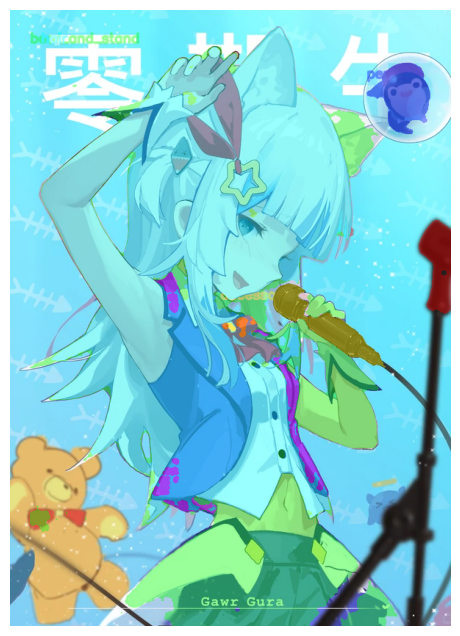

microphone | multi-instance | score = 0.7208 | area = 0.0172


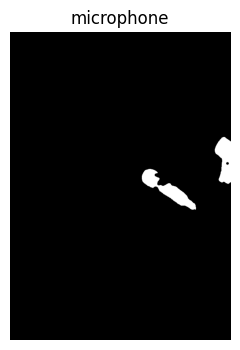

bear_and_stand | multi-class | score = 0.3971 | area = 0.4652


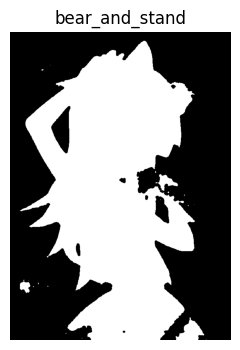

penguin | single-instance | score = 0.36 | area = 0.0101


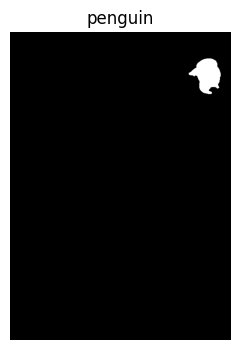

accessory | multi-instance | score = 0.3888 | area = 0.0152


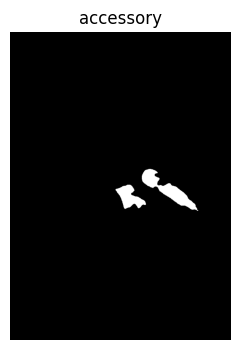

vest | multi-instance | score = 0.4431 | area = 0.0524


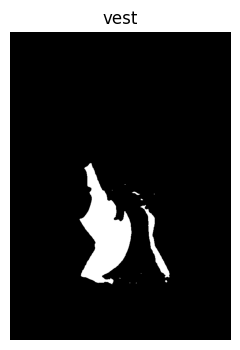

hair | multi-instance | score = 0.3075 | area = 0.3282


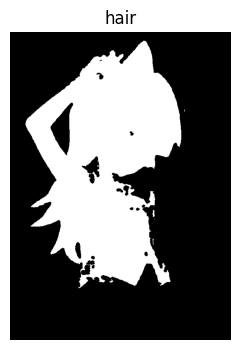

In [18]:
view_idx = 0
row = seg_rows[view_idx]

print("image_id =", row["image_id"])
print("overlay_path =", row["overlay_path"])

if row["overlay_path"] is not None:
    plt.figure(figsize=(8, 8))
    plt.imshow(Image.open(row["overlay_path"]))
    plt.axis("off")
    plt.show()

for c in row["segmentation_candidates"]:
    print(
        c["label"],
        "|", c["mask_type"],
        "| score =", round(c["score"], 4),
        "| area =", round(c["mask_area_ratio"], 4)
    )
    plt.figure(figsize=(4, 4))
    plt.imshow(Image.open(c["mask_path"]), cmap="gray")
    plt.title(c["label"])
    plt.axis("off")
    plt.show()

In [19]:
# 整理现有 segmentation 输出为按图分目录
from pathlib import Path
import json
import shutil
import os

# ========= 配置 =========
ROOT = Path("/kaggle/working/batch_segmentation")   # 这里改成你当前 segmentation 输出根目录
FLAT_JSONL = ROOT / "segmentation_results.jsonl"
FLAT_MASK_DIR = ROOT / "masks"
FLAT_OVERLAY_DIR = ROOT / "overlays"

RECORDS_DIR = ROOT / "records"

# "move" = 搬运（推荐，不保留旧平铺文件）
# "copy" = 复制（会保留两份，不推荐）
TRANSFER_MODE = "move"

# True: 用整理后的内容直接覆盖原 segmentation_results.jsonl
# False: 另存成 segmentation_results_grouped.jsonl
OVERWRITE_ORIGINAL_JSONL = True

print("ROOT =", ROOT)
print("FLAT_JSONL exists =", FLAT_JSONL.exists())
print("FLAT_MASK_DIR exists =", FLAT_MASK_DIR.exists())
print("FLAT_OVERLAY_DIR exists =", FLAT_OVERLAY_DIR.exists())

RECORDS_DIR.mkdir(parents=True, exist_ok=True)


# ========= 工具函数 =========
def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def write_jsonl(path, rows):
    with open(path, "w", encoding="utf-8") as f:
        for obj in rows:
            f.write(json.dumps(obj, ensure_ascii=False) + "\n")


import re

def safe_name(x):
    x = str(x).strip().lower()

    x = x.replace("&", "_and_")
    x = x.replace("/", "_")
    x = x.replace("\\", "_")
    x = x.replace(" ", "_")

    x = re.sub(r"[^a-z0-9._-]", "_", x)
    x = re.sub(r"_+", "_", x).strip("._")

    return x[:80] if x else "mask"


def transfer_file(src, dst, mode="move"):
    src = Path(src)
    dst = Path(dst)
    dst.parent.mkdir(parents=True, exist_ok=True)

    if not src.exists():
        return None

    # 如果已经在目标位置，就直接返回
    try:
        if src.resolve() == dst.resolve():
            return str(dst)
    except:
        pass

    if mode == "move":
        if dst.exists():
            # 目标已存在则先删，避免 move 失败
            dst.unlink()
        shutil.move(str(src), str(dst))
    elif mode == "copy":
        shutil.copy2(str(src), str(dst))
    else:
        raise ValueError("TRANSFER_MODE must be 'move' or 'copy'")

    return str(dst)


def remove_dir_if_empty(path):
    path = Path(path)
    if path.exists() and path.is_dir():
        if len(list(path.iterdir())) == 0:
            path.rmdir()


# ========= 主逻辑 =========
rows = load_jsonl(FLAT_JSONL)
print("loaded rows =", len(rows))

new_rows = []
moved_masks = 0
moved_overlays = 0
missing_masks = 0
missing_overlays = 0

for row in rows:
    image_id = row["image_id"]
    record_dir = RECORDS_DIR / image_id
    record_masks_dir = record_dir / "masks"
    record_dir.mkdir(parents=True, exist_ok=True)
    record_masks_dir.mkdir(parents=True, exist_ok=True)

    new_row = dict(row)
    new_row["record_dir"] = str(record_dir)

    # ===== 处理 overlay =====
    overlay_path = row.get("overlay_path")
    if overlay_path:
        src_overlay = Path(overlay_path)
        overlay_suffix = src_overlay.suffix if src_overlay.suffix else ".png"
        dst_overlay = record_dir / f"overlay{overlay_suffix}"

        new_overlay_path = transfer_file(src_overlay, dst_overlay, mode=TRANSFER_MODE)
        if new_overlay_path is None:
            missing_overlays += 1
            new_row["overlay_path"] = None
        else:
            moved_overlays += 1
            new_row["overlay_path"] = new_overlay_path
    else:
        new_row["overlay_path"] = None

    # ===== 处理 masks =====
    new_candidates = []
    for i, cand in enumerate(row.get("segmentation_candidates", [])):
        new_cand = dict(cand)

        src_mask = Path(cand["mask_path"])
        mask_suffix = src_mask.suffix if src_mask.suffix else ".png"
        dst_mask = record_masks_dir / f"{i:02d}_{safe_name(cand['label'])}{mask_suffix}"

        new_mask_path = transfer_file(src_mask, dst_mask, mode=TRANSFER_MODE)
        if new_mask_path is None:
            missing_masks += 1
            new_cand["mask_path"] = None
        else:
            moved_masks += 1
            new_cand["mask_path"] = new_mask_path

        new_candidates.append(new_cand)

    new_row["segmentation_candidates"] = new_candidates

    # ===== 写每张图自己的 meta.json =====
    meta_path = record_dir / "meta.json"
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(new_row, f, ensure_ascii=False, indent=2)

    new_rows.append(new_row)


# ========= 写回总索引 =========
if OVERWRITE_ORIGINAL_JSONL:
    tmp_jsonl = ROOT / "segmentation_results.tmp.jsonl"
    write_jsonl(tmp_jsonl, new_rows)
    tmp_jsonl.replace(FLAT_JSONL)
    final_jsonl = FLAT_JSONL
else:
    final_jsonl = ROOT / "segmentation_results_grouped.jsonl"
    write_jsonl(final_jsonl, new_rows)

print("\n整理完成")
print("final jsonl =", final_jsonl)
print("moved_masks =", moved_masks)
print("moved_overlays =", moved_overlays)
print("missing_masks =", missing_masks)
print("missing_overlays =", missing_overlays)

# ========= 如果是 move，尝试删除空的旧平铺目录 =========
if TRANSFER_MODE == "move":
    remove_dir_if_empty(FLAT_MASK_DIR)
    remove_dir_if_empty(FLAT_OVERLAY_DIR)

    print("\n清理后目录状态：")
    print("FLAT_MASK_DIR exists =", FLAT_MASK_DIR.exists())
    print("FLAT_OVERLAY_DIR exists =", FLAT_OVERLAY_DIR.exists())

print("\nrecords 目录示例：")
for p in sorted(RECORDS_DIR.iterdir())[:3]:
    print(" -", p)

ROOT = /kaggle/working/batch_segmentation
FLAT_JSONL exists = True
FLAT_MASK_DIR exists = True
FLAT_OVERLAY_DIR exists = True
loaded rows = 314

整理完成
final jsonl = /kaggle/working/batch_segmentation/segmentation_results.jsonl
moved_masks = 1569
moved_overlays = 313
missing_masks = 0
missing_overlays = 0

清理后目录状态：
FLAT_MASK_DIR exists = False
FLAT_OVERLAY_DIR exists = False

records 目录示例：
 - /kaggle/working/batch_segmentation/records/000000_85013611_p0_master1200
 - /kaggle/working/batch_segmentation/records/000001_85027430_p0_master1200
 - /kaggle/working/batch_segmentation/records/000002_85033409_p0_master1200


In [20]:
# 压缩输出文件
from pathlib import Path
import shutil

src_dir = Path("/kaggle/working/batch_segmentation")
zip_base = Path("/kaggle/working/batch_segmentation")  # 不带 .zip

zip_path = shutil.make_archive(
    base_name=str(zip_base),
    format="zip",
    root_dir=str(src_dir.parent),
    base_dir=src_dir.name
)

print("ZIP saved to:", zip_path)
print("Exists:", Path(zip_path).exists())
print("Size (MB):", round(Path(zip_path).stat().st_size / 1024 / 1024, 2))

shutil.rmtree(Path("/kaggle/working/batch_segmentation"))
print("deleted original folder")

ZIP saved to: /kaggle/working/batch_segmentation.zip
Exists: True
Size (MB): 136.77
deleted original folder
